# Random Forest

Approach: flatten each (30, 126) sequence into a feature vector of summary statistics over time, then train a Random Forest model

Evaluation: 5 Kfold for tuning hyperparamters, then testing with the held out data.

In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

DATA_DIR = r'D:\MLproject\code\processed_data_New1'
RANDOM_SEED = 80

***Loading Data***

Cell loads the preprocessed data we have from the preprocessing step/jupyter notebook. The development/training set contains 18 participants used for cross-validation with our implemented KGroupFolds, while the last 3 participants are not included in the dev.npz, so we can be sure that the model is learning the actual sign and not learning from the participants' specific signing patterns.

In [2]:
# load data
dev = np.load(os.path.join(DATA_DIR, 'dev.npz'))
test = np.load(os.path.join(DATA_DIR, 'test.npz'))
folds = np.load(os.path.join(DATA_DIR, 'cv_folds.npz'))
classes = np.load(os.path.join(DATA_DIR, 'classes.npy'), allow_pickle=True)

X_dev, y_dev, groups_dev = dev['X'], dev['y'], dev['groups']
X_test, y_test = test['X'], test['y']

print(f'Dev: {X_dev.shape}, {len(np.unique(groups_dev))} participants')
print(f'Test: {X_test.shape}')
print(f'Classes: {len(classes)}')
print(f'Random chance: {100/len(classes):.1f}%')

Dev: (16007, 30, 274), 18 participants
Test: (2841, 30, 274)
Classes: 50
Random chance: 2.0%


***Feature Engineering for RF Model***

Since the random forest (RF) can't handle the timing dimensions, we collapse the 30 frames into summary statistics per each feature. We are splitting the data between position data (first 137) and velocity/movement data (last 137), then used specific functions to get features for each. 

Position stats: mean, std, min, max, range, and displacement (last frame compared to first frame). This was to capture where the body was and the relativity of the movement to where the body actually was located.

Veloctiy stats: mean, std, and abs. max. These were added in after running our first few implementations and realizing that just position data wasn't enough for the models to learn based on timing and movement. 

In [3]:
#summarizing the (30,274) into a signle feature vecotr for the random forest
numPos = 137

def extract_rf_features(X):
    # position stats across time
    pos = X[:, :, :numPos]  
    vel = X[:, :, numPos:]  

    # position stats across time
    f_mean = pos.mean(axis=1)
    f_std = pos.std(axis=1)
    f_min = pos.min(axis=1)
    f_max = pos.max(axis=1)
    f_range = f_max - f_min
    f_disp = pos[:, -1, :] - pos[:, 0, :] 

    # velocity stats
    v_mean = vel.mean(axis=1)
    v_std = vel.std(axis=1)
    v_absmax = np.abs(vel).max(axis=1)  

    return np.concatenate([f_mean, f_std, f_min, f_max, f_range, f_disp, v_mean, v_std, v_absmax], axis=1)
X_dev_rf  = extract_rf_features(X_dev)
X_test_rf = extract_rf_features(X_test)
print(f'Dev feature matrix:  {X_dev_rf.shape}')
print(f'Test feature matrix: {X_test_rf.shape}')

Dev feature matrix:  (16007, 1233)
Test feature matrix: (2841, 1233)


### Baseline 5 Fold Cross Validation ###

This cell will run a baseline RF model that has parameters, I will briefly describe why we chose the values we did...

**n_estimators** = 300: this is a middle ground value, that is not too big/small. Because with a smaller tree, it might be quicker, but the predictions we get would be noisy/unstable because it would only see a subset of the dataset. Too many wouldn't cause any problems per say but it would cause a super long time for compute with not enough meaningful return.

**max_depth** = None: We chose this so we can get deep trees, so that it avoids underfitting with smaller trees. We are also relying mostly on the ensemble averaging to control the overfitting problem with deeper trees. 

**min_sample_split** = 2: This just lets the tree grow fully as long as a node has 2 samples. 

Also for the folds, we explained it in the preprocessing so jsut reference that if needed

In [4]:
# 5 folds to do cross validation
n_folds = 5
fold_accs = []

for fold in range(n_folds):
    tr = folds[f'fold_{fold}_train']
    va = folds[f'fold_{fold}_val']
    # base RF for each fold 
    rf = RandomForestClassifier(n_estimators=300, max_depth=None, min_samples_split=2, n_jobs=-1, random_state=RANDOM_SEED,)
    rf.fit(X_dev_rf[tr], y_dev[tr])
    acc = rf.score(X_dev_rf[va], y_dev[va])
    fold_accs.append(acc)
    print(f'Fold {fold+1}: {acc*100:.2f}%')

print(f'\nMean CV accuracy: {np.mean(fold_accs)*100:.2f}% ± {np.std(fold_accs)*100:.2f}%')

Fold 1: 39.37%
Fold 2: 31.01%
Fold 3: 33.16%
Fold 4: 52.95%
Fold 5: 23.63%

Mean CV accuracy: 36.02% ± 9.84%


### Hyper Parameter Tuning ###

So I do want to say, we couldn't do a super big and conclusive parameter grtid for the RF since there was no way we could GPU accelerate the processes, without parallization but would have taken too long. We also knew this was going to be the worst model since it lost all the timing information and realied on the min/max type of inputs. 

**n_estimators** : Looking for where our model benefits from the increased amount of trees but doesn't level 

In [5]:
# hyperparamater tuning... testing a ton of different things.

param_grid = [
    {'n_estimators': 200, 'max_depth': None, 'max_features': 'sqrt'},
    {'n_estimators':400, 'max_depth': None, 'max_features': 'sqrt'},
    {'n_estimators': 500, 'max_depth': None, 'max_features': 'sqrt'},
    {'n_estimators': 500, 'max_depth': 40,   'max_features': 'sqrt'},
    {'n_estimators': 500, 'max_features': 0.3, 'min_samples_leaf': 1},
    {'n_estimators': 500, 'max_depth': None, 'max_features': 'log2'},
    {'n_estimators': 800, 'max_depth': None, 'max_features': 'sqrt'},
]

results = []
for params in param_grid:
    accs = []
    for fold in range(n_folds):
        tr = folds[f'fold_{fold}_train']
        va = folds[f'fold_{fold}_val']
        rf = RandomForestClassifier(**params, n_jobs=-1, random_state=RANDOM_SEED)
        rf.fit(X_dev_rf[tr], y_dev[tr])
        accs.append(rf.score(X_dev_rf[va], y_dev[va]))
    mean_acc = np.mean(accs)
    results.append((params, mean_acc, np.std(accs)))
    print(f'{params}: {mean_acc*100:.2f}% ± {np.std(accs)*100:.2f}%')

best_params, best_acc, xx = max(results, key=lambda r: r[1])
print(f'\nBest: {best_params} - {best_acc*100:.2f}%')

{'n_estimators': 200, 'max_depth': None, 'max_features': 'sqrt'}: 35.75% ± 9.73%
{'n_estimators': 400, 'max_depth': None, 'max_features': 'sqrt'}: 36.25% ± 9.96%
{'n_estimators': 500, 'max_depth': None, 'max_features': 'sqrt'}: 36.20% ± 9.94%
{'n_estimators': 500, 'max_depth': 40, 'max_features': 'sqrt'}: 36.12% ± 9.56%
{'n_estimators': 500, 'max_features': 0.3, 'min_samples_leaf': 1}: 37.11% ± 10.13%
{'n_estimators': 500, 'max_depth': None, 'max_features': 'log2'}: 33.57% ± 9.51%
{'n_estimators': 800, 'max_depth': None, 'max_features': 'sqrt'}: 36.44% ± 9.77%

Best: {'n_estimators': 500, 'max_features': 0.3, 'min_samples_leaf': 1} - 37.11%


In [6]:
final_rf = RandomForestClassifier(**best_params, n_jobs=-1, random_state=RANDOM_SEED)
final_rf.fit(X_dev_rf, y_dev)
y_pred = final_rf.predict(X_test_rf)
test_acc = accuracy_score(y_test, y_pred)
print(f'Held out test accuracy: {test_acc*100:.2f}%')
print(f'Random chance: {100/len(classes):.1f}%')

Held out test accuracy: 39.81%
Random chance: 2.0%


In [7]:
# class report
print(classification_report(y_test, y_pred, target_names=classes, zero_division=0))

              precision    recall  f1-score   support

    airplane       0.58      0.57      0.57        58
   alligator       0.34      0.32      0.33        57
         any       0.23      0.16      0.19        56
         bee       0.35      0.50      0.41        54
        bird       0.40      0.55      0.46        60
        blow       0.37      0.21      0.27        62
        boat       0.32      0.40      0.36        57
         cat       0.22      0.49      0.31        57
       close       0.19      0.06      0.09        54
         cow       0.71      0.70      0.71        57
         cry       0.44      0.54      0.48        54
         cut       0.48      0.44      0.46        57
       dance       0.49      0.50      0.49        48
         dog       0.21      0.24      0.22        59
        down       0.30      0.16      0.21        51
       drink       0.69      0.37      0.48        60
        drop       0.37      0.13      0.19        53
        duck       0.31    

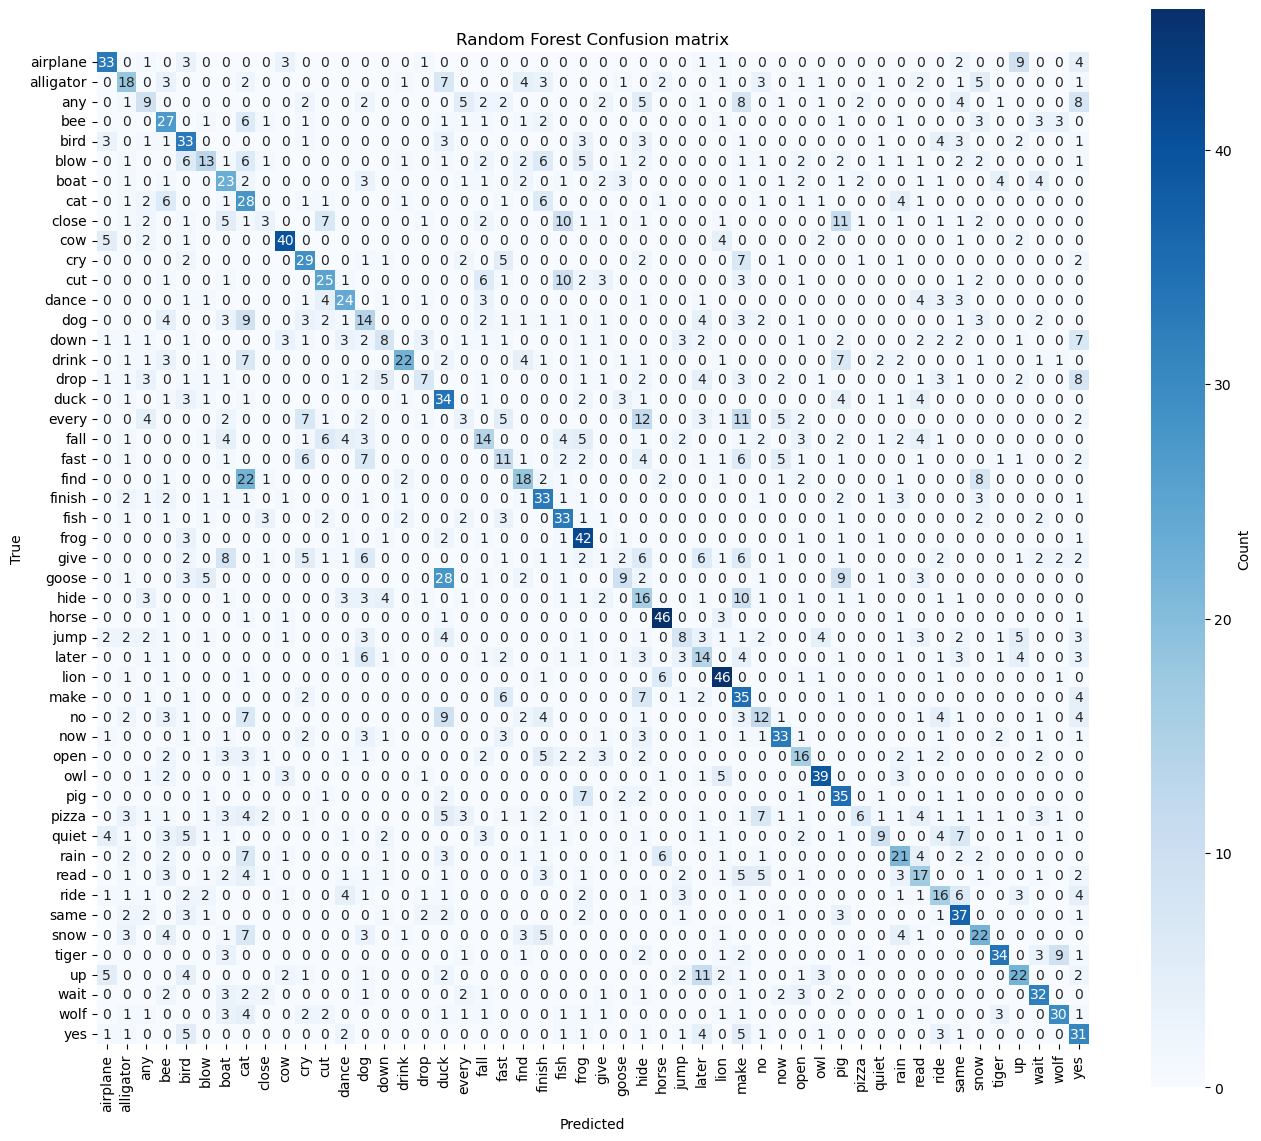


Top 10 confused pairs:
goose mistaken as duck : 28 times
find mistaken as cat : 22 times
every mistaken as hide : 12 times
up mistaken as later : 11 times
close mistaken as pig : 11 times
every mistaken as make : 11 times
close mistaken as fish : 10 times
cut mistaken as fish : 10 times
hide mistaken as make : 10 times
no mistaken as duck : 9 times


In [8]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(16, 14))
sns.heatmap(cm, annot=True, fmt ='d',  xticklabels=classes, yticklabels=classes, cmap='Blues', cbar_kws={'label': 'Count'}, square=True)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Random Forest Confusion matrix')
plt.xticks(rotation=90)
plt.show()

# Top confused pairs
cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)
print('\nTop 10 confused pairs:')
flat_idx = np.argsort(cm_no_diag.ravel())[-10:][::-1]
for idx in flat_idx:
    i, j = np.unravel_index(idx, cm_no_diag.shape)
    if cm_no_diag[i, j] > 0:
        print(f'{classes[i]} mistaken as {classes[j]} : {cm_no_diag[i, j]} times')

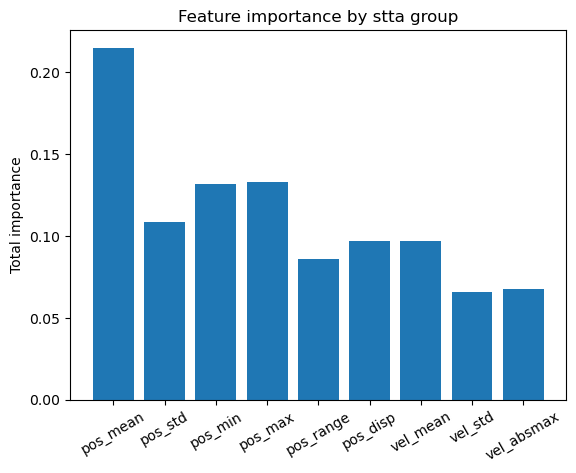

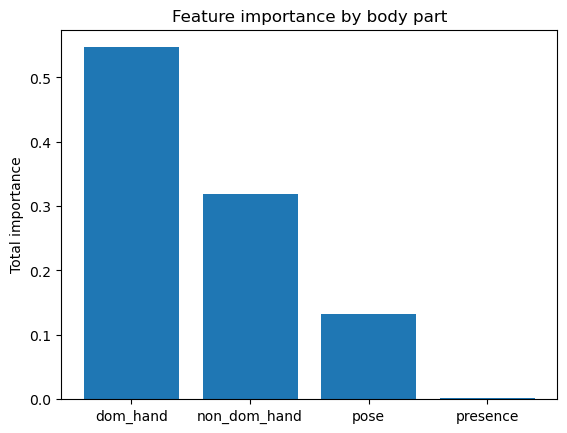

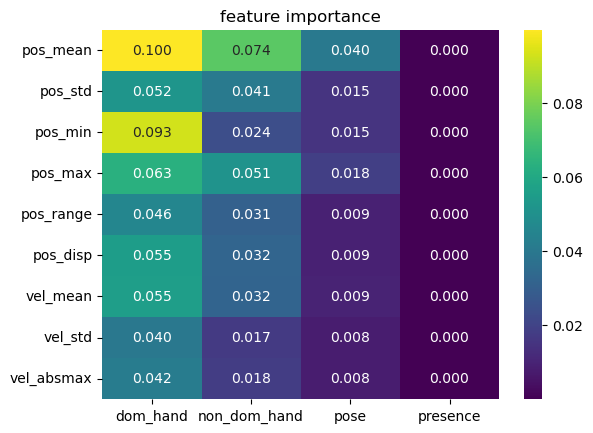


Total importance by body part:
dom_hand: 54.7%
non_dom_hand: 31.9%
pose: 13.3%
presence: 0.1%


In [9]:
stat_groups = ['pos_mean', 'pos_std', 'pos_min', 'pos_max', 'pos_range', 'pos_disp', 'vel_mean', 'vel_std', 'vel_absmax']
body_parts = {
    'dom_hand': slice(0, 63),
    'non_dom_hand': slice(63, 126),
    'pose': slice(126, 135),
    'presence': slice(135, 137),
}

importances = final_rf.feature_importances_.reshape(len(stat_groups), numPos)

# stat group
group_totals = importances.sum(axis=1)
plt.figure()
plt.bar(stat_groups, group_totals)
plt.ylabel('Total importance')
plt.title('Feature importance by stta group')
plt.xticks(rotation=30)
plt.show()

# body part
part_totals = {name: importances[:, sl].sum() for name, sl in body_parts.items()}
plt.figure()
plt.bar(part_totals.keys(), part_totals.values())
plt.ylabel('Total importance')
plt.title('Feature importance by body part')
plt.show()

# telling us which stats actually are used and matter
heatmap = np.zeros((len(stat_groups), len(body_parts)))
for i, o in enumerate(stat_groups):
    for j, (c, sl) in enumerate(body_parts.items()):
        heatmap[i, j] = importances[i, sl].sum()

plt.figure()
sns.heatmap(heatmap, xticklabels=list(body_parts.keys()), yticklabels=stat_groups, annot=True, fmt='.3f', cmap='viridis')
plt.title('feature importance')
plt.savefig('rf_importance_heatmap.png', dpi=120)
plt.show()

print('\nTotal importance by body part:')
for name, val in part_totals.items():
    print(f'{name}: {val*100:.1f}%')